## Deteksi Kecanduan Smartphone: Hybrid CNN + XGBoost (Versi Final)

**Judul Penelitian:** Deteksi Kecanduan Smartphone Menggunakan Arsitektur Hybrid CNN sebagai Feature Extractor dan XGBoost sebagai Meta-Classifier dengan Pipeline yang Bebas Data Leakage

##  Daftar Perbaikan dari Versi Sebelumnya

| # | Aspek | Versi Lama | Versi Baru |
|---|-------|------------|------------|
| 1 | **Data Quality** | Dataset raw, 819 NaN target | Cleaning + outlier removal + quality audit |
| 2 | **Class Imbalance** | SMOTE saja | Perbandingan: SMOTE vs Class Weight vs ADASYN → pilih terbaik |
| 3 | **CV Pipeline** | Data leakage (scaler fit sebelum split) | Scaler & resampling di DALAM fold |
| 4 | **Feature Selection** | Semua fitur masuk | Mutual Information + Recursive Feature Elimination |
| 5 | **CNN Role** | Hanya sebagai classifier paralel | CNN sebagai Feature Extractor → output ke XGBoost |
| 6 | **Feature Ordering** | Random | Diurutkan semantik per group sebelum Conv1D |
| 7 | **Hyperparameter** | 50 trials XGB, 20 CNN | 100 trials XGB, 50 CNN |
| 8 | **Evaluasi** | Test set saja | Test set + CV yang valid + statistical significance |


## 1. Import Library & Setup

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES (jalankan sekali jika belum terinstall)
# ============================================================
# !pip install optuna shap imbalanced-learn xgboost tensorflow scikit-learn
#             matplotlib seaborn lightgbm scipy

# ── Basic ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

# ── Visualisasi ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Preprocessing ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Feature Selection ────────────────────────────────────────
from sklearn.feature_selection import (
    mutual_info_classif, SelectKBest, RFECV
)

# ── Metrics ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, cohen_kappa_score,
    matthews_corrcoef, ConfusionMatrixDisplay
)

# ── Class Imbalance Handling ──────────────────────────────────
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# ── Tree Models ──────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# ── Deep Learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, Flatten, MaxPooling1D, Input,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ── Hyperparameter Optimization ──────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Statistical Test ─────────────────────────────────────────
from scipy import stats

# ── SHAP ─────────────────────────────────────────────────────
import shap

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Semua library berhasil diimport!")
print(f"   TensorFlow : {tf.__version__}")
print(f"   Numpy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")

✅ Semua library berhasil diimport!
   TensorFlow : 2.21.0
   Numpy      : 2.4.4
   Pandas     : 2.3.3


## 1.5  MLflow Setup

In [ ]:
# ============================================================
# MLflow SETUP — tambahkan di blok import
# ============================================================
import mlflow
import mlflow.sklearn
import mlflow.tensorflow
import mlflow.xgboost
from mlflow import MlflowClient

# Konfigurasi tracking URI (ganti path sesuai environment)
MLFLOW_TRACKING_URI = "file:///E:/Python - Project/phone-addiction-detection/mlruns"
EXPERIMENT_NAME     = "SmartphoneAddiction_HybridCNN_XGBoost"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow configured!")
print(f"   Tracking URI : {MLFLOW_TRACKING_URI}")
print(f"   Experiment   : {EXPERIMENT_NAME}")
print(f"   MLflow UI    : jalankan → mlflow ui --port 5000")


✅ MLflow configured!
   Tracking URI : file:///D:/Collage/DataMining/mlruns
   Experiment   : SmartphoneAddiction_HybridCNN_XGBoost
   MLflow UI    : jalankan → mlflow ui --port 5000


## 2. Load & Audit Kualitas Dataset

In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================
FILE_PATH = r'E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
TARGET    = 'addiction_level'

df_raw = pd.read_csv(FILE_PATH)

print("=" * 60)
print("📊 AUDIT KUALITAS DATA AWAL")
print("=" * 60)
print(f"Shape         : {df_raw.shape}")
print(f"Duplikat      : {df_raw.duplicated().sum()}")
print(f"\nMissing Values per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct(%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])
print(f"\nTipe Data:")
print(df_raw.dtypes)

📊 AUDIT KUALITAS DATA AWAL
Shape         : (7500, 16)
Duplikat      : 0

Missing Values per Kolom:
                 Count  Pct(%)
addiction_level    819   10.92

Tipe Data:
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object



Distribusi Target (termasuk NaN):
addiction_level
Moderate    2874
Severe      2434
Mild        1373
NaN          819
Name: count, dtype: int64


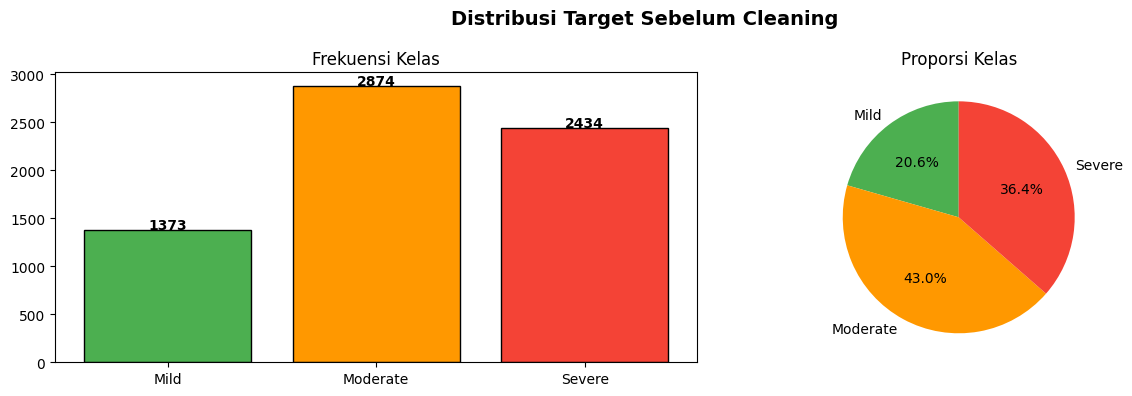

In [ ]:
# ============================================================
# CEK DISTRIBUSI TARGET
# ============================================================
target_order  = ['Mild', 'Moderate', 'Severe']
target_colors = ['#4CAF50', '#FF9800', '#F44336']

print("\nDistribusi Target (termasuk NaN):")
print(df_raw[TARGET].value_counts(dropna=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Target Sebelum Cleaning', fontsize=14, fontweight='bold')

df_notna = df_raw.dropna(subset=[TARGET])
counts   = df_notna[TARGET].value_counts()[target_order]

axes[0].bar(target_order, counts.values, color=target_colors, edgecolor='black')
axes[0].set_title('Frekuensi Kelas')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=target_order, colors=target_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.savefig('fig1_distribusi_target_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning & Quality Enhancement

In [ ]:
# ============================================================
# 3.1 HAPUS DUPLIKAT & MISSING TARGET
# ============================================================
df = df_raw.copy()

# Hapus duplikat
n_before = len(df)
df = df.drop_duplicates()
print(f"Duplikat dihapus   : {n_before - len(df)} baris")

# Hapus baris tanpa target
n_before = len(df)
df = df.dropna(subset=[TARGET])
print(f"NaN target dihapus : {n_before - len(df)} baris")
print(f"Sisa data          : {len(df)} baris")

Duplikat dihapus   : 0 baris
NaN target dihapus : 819 baris
Sisa data          : 6681 baris


In [ ]:
# ============================================================
# 3.2 VALIDASI RANGE NILAI FITUR NUMERIK
# (Domain knowledge: jam per hari max 24, dll.)
# ============================================================
valid_ranges = {
    'age'                    : (5, 100),
    'daily_screen_time_hours': (0, 24),
    'social_media_hours'     : (0, 24),
    'gaming_hours'           : (0, 24),
    'work_study_hours'       : (0, 24),
    'sleep_hours'            : (0, 24),
    'notifications_per_day'  : (0, 5000),
    'app_opens_per_day'      : (0, 1000),
    'weekend_screen_time'    : (0, 24),
}

n_before = len(df)
mask_valid = pd.Series([True] * len(df), index=df.index)

for col, (lo, hi) in valid_ranges.items():
    if col in df.columns:
        col_mask = df[col].between(lo, hi)
        invalid  = (~col_mask).sum()
        if invalid > 0:
            print(f"  ⚠️  {col}: {invalid} nilai di luar [{lo}, {hi}]")
        mask_valid &= col_mask

df = df[mask_valid]
print(f"\nBaris invalid range dihapus : {n_before - len(df)}")
print(f"Sisa data                   : {len(df)} baris")


Baris invalid range dihapus : 0
Sisa data                   : 6681 baris


In [ ]:
# ============================================================
# 3.3 LOGICAL CONSISTENCY CHECK
# Total jam aktif tidak boleh melebihi 24 jam
# ============================================================
time_cols = ['social_media_hours', 'gaming_hours', 'work_study_hours']
if all(c in df.columns for c in time_cols):
    df['_total_active'] = df[time_cols].sum(axis=1)
    n_before = len(df)
    df = df[df['_total_active'] <= 24]
    df = df.drop(columns=['_total_active'])
    print(f"Baris inconsistent time dihapus: {n_before - len(df)}")

print(f"Dataset final setelah cleaning: {df.shape}")

Baris inconsistent time dihapus: 0
Dataset final setelah cleaning: (6681, 16)


In [ ]:
# ============================================================
# 3.4 DETEKSI & HAPUS OUTLIER EKSTREM (IQR Method)
# Hanya untuk fitur numerik kritis — tidak hapus terlalu agresif
# ============================================================
outlier_cols = [
    'daily_screen_time_hours', 'notifications_per_day', 'app_opens_per_day'
]

n_before = len(df)
for col in outlier_cols:
    if col not in df.columns:
        continue
    Q1  = df[col].quantile(0.01)   # gunakan 1% – 99% agar tidak terlalu agresif
    Q99 = df[col].quantile(0.99)
    df  = df[df[col].between(Q1, Q99)]

print(f"Outlier ekstrem (1-99 pct) dihapus : {n_before - len(df)} baris")
print(f"Dataset final                       : {df.shape}")

Outlier ekstrem (1-99 pct) dihapus : 314 baris
Dataset final                       : (6367, 16)


In [ ]:
# ============================================================
# 3.5 IMPUTASI MISSING VALUE FITUR (bukan target)
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = df.select_dtypes(include='object').columns
cat_cols_raw = [c for c in cat_cols_raw if c != TARGET]

# Numerik: median
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Kategorik: mode
for col in cat_cols_raw:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Total NaN setelah imputasi: {df.isnull().sum().sum()}")
print("\nDistribusi target setelah cleaning:")
print(df[TARGET].value_counts())

Total NaN setelah imputasi: 0

Distribusi target setelah cleaning:
addiction_level
Moderate    2740
Severe      2316
Mild        1311
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

In [ ]:
# ============================================================
# 4.1 STATISTIK DESKRIPTIF
# ============================================================
print("=" * 60)
print("STATISTIK DESKRIPTIF FITUR NUMERIK")
print("=" * 60)
num_feat = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
num_feat = [c for c in num_feat if c in df.columns]
print(df[num_feat].describe().round(2).to_string())

STATISTIK DESKRIPTIF FITUR NUMERIK
           age  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time
count  6367.00                  6367.00             6367.00       6367.00           6367.00      6367.00                6367.00            6367.00              6367.00
mean     26.57                     7.87                3.40          2.02              3.24         6.74                 134.33              97.88                 9.62
std       5.20                     2.46                1.59          1.15              1.60         1.29                  65.35              47.81                 2.57
min      18.00                     3.09                0.50          0.00              0.50         4.50                  22.00              16.00                 3.63
25%      22.00                     5.96                2.03          1.02              1.84         5.64                  77.

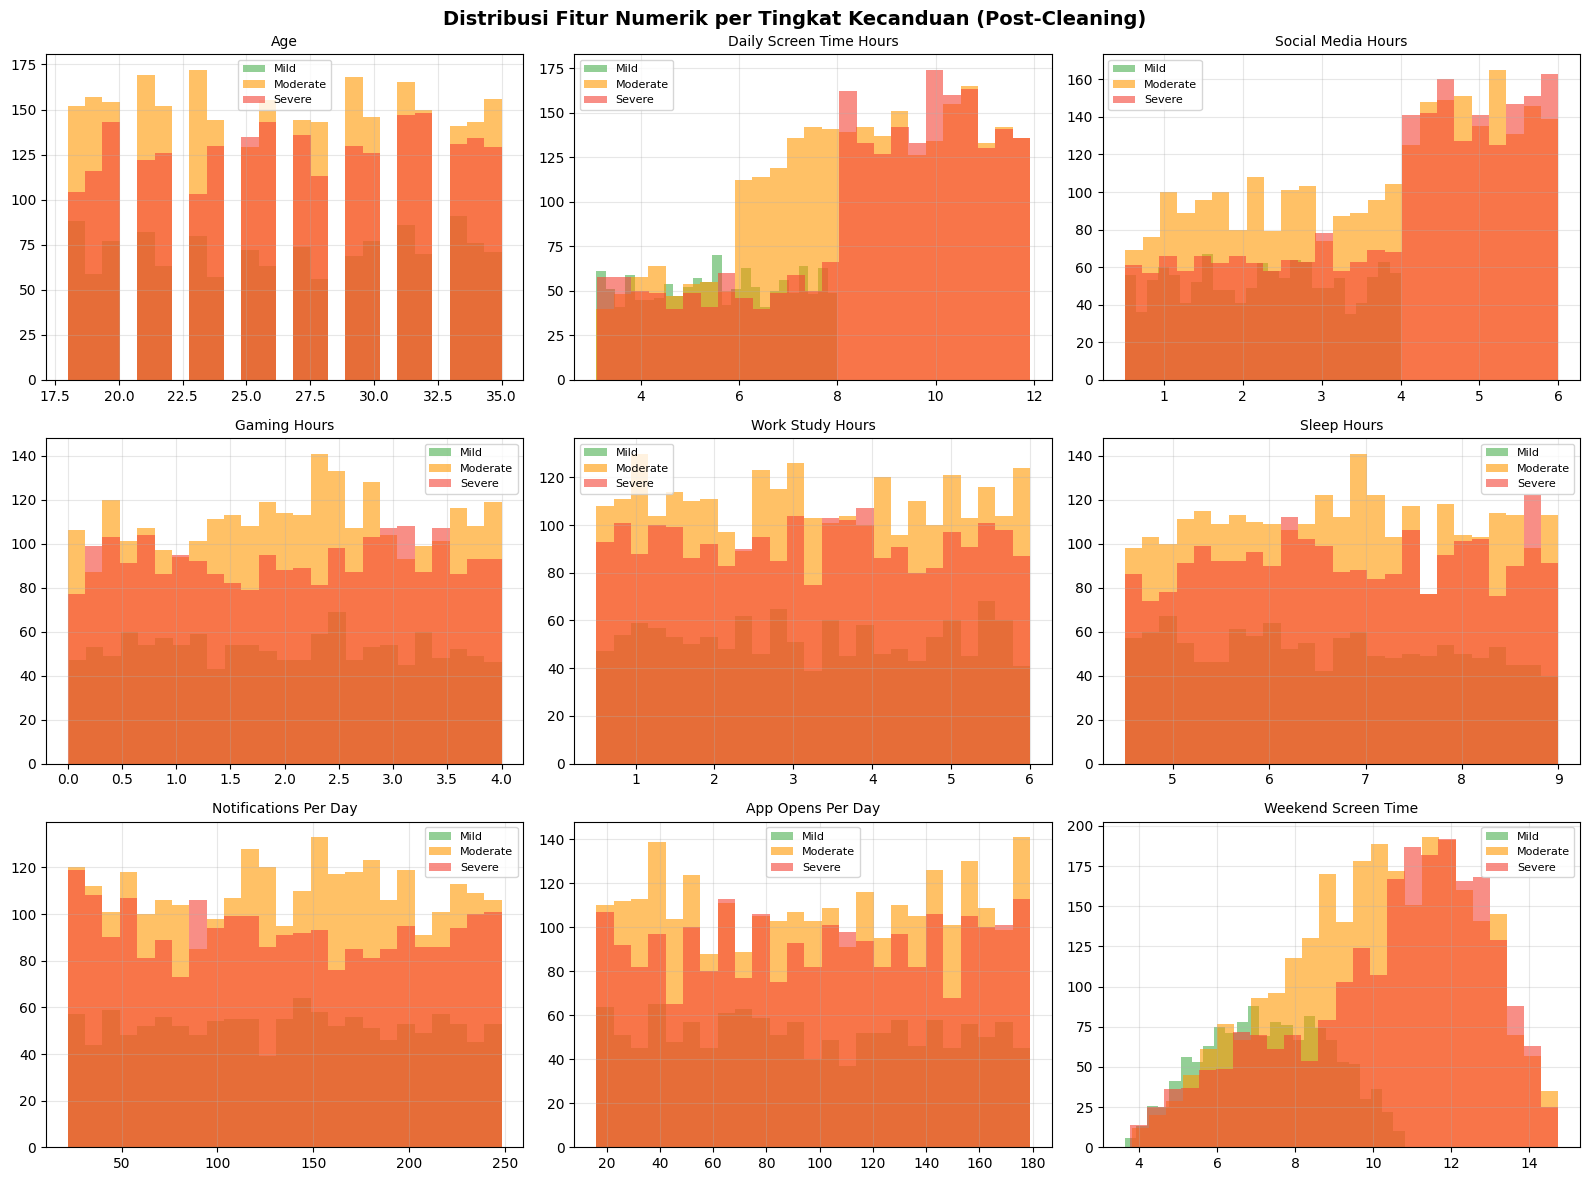

In [ ]:
# ============================================================
# 4.2 DISTRIBUSI FITUR NUMERIK PER KELAS
# ============================================================
palette = {'Mild': '#4CAF50', 'Moderate': '#FF9800', 'Severe': '#F44336'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribusi Fitur Numerik per Tingkat Kecanduan (Post-Cleaning)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_feat[:9]):
    for label in target_order:
        subset = df[df[TARGET] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.6, label=label, color=palette[label])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

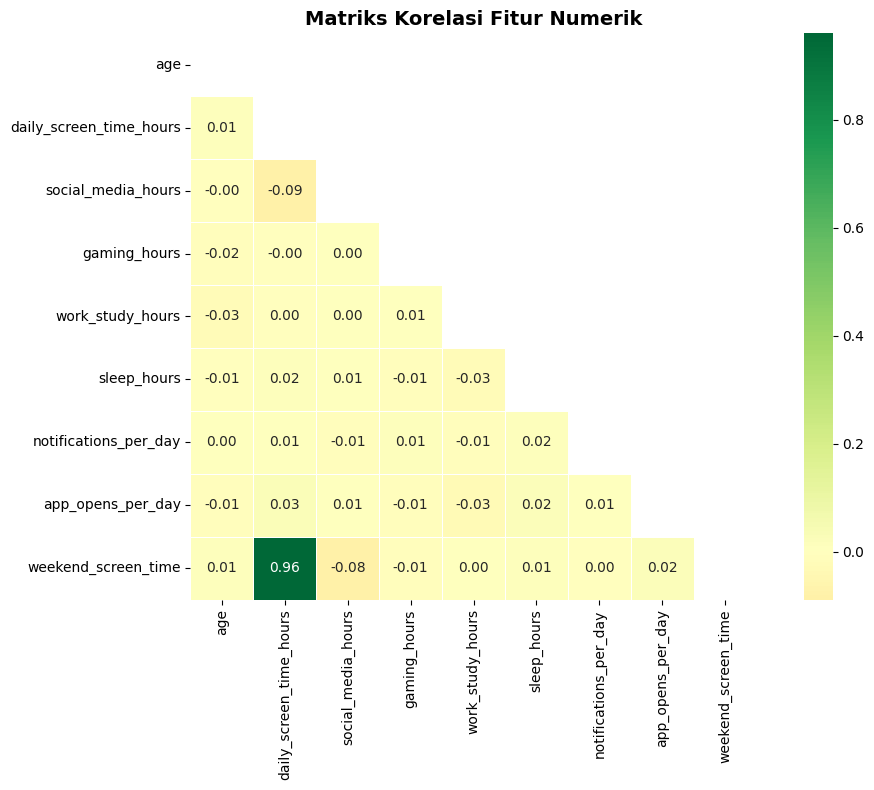

In [ ]:
# ============================================================
# 4.3 HEATMAP KORELASI
# ============================================================
corr = df[num_feat].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Encoding

In [ ]:
# ============================================================
# 5.1 FEATURE ENGINEERING — Fitur Domain-Specific
# ============================================================
df_fe = df.copy()

eps = 1e-5  # avoid division by zero

# ── Group A: Usage Ratios ─────────────────────────────────────
df_fe['social_ratio']     = df_fe['social_media_hours'] / (df_fe['daily_screen_time_hours'] + eps)
df_fe['gaming_ratio']     = df_fe['gaming_hours']       / (df_fe['daily_screen_time_hours'] + eps)
df_fe['productive_ratio'] = df_fe['work_study_hours']   / (df_fe['daily_screen_time_hours'] + eps)
df_fe['passive_ratio']    = (df_fe['social_media_hours'] + df_fe['gaming_hours']) / (df_fe['daily_screen_time_hours'] + eps)

# ── Group B: Wellbeing Indicators ────────────────────────────
df_fe['sleep_deficit']       = np.maximum(0, 7 - df_fe['sleep_hours'])
df_fe['sleep_screen_ratio']  = df_fe['sleep_hours'] / (df_fe['daily_screen_time_hours'] + eps)
df_fe['leisure_total']       = df_fe['social_media_hours'] + df_fe['gaming_hours']

# ── Group C: Behavioral Intensity ────────────────────────────
df_fe['notif_density']    = df_fe['notifications_per_day'] / (df_fe['daily_screen_time_hours'] + eps)
df_fe['app_open_rate']    = df_fe['app_opens_per_day']     / (df_fe['daily_screen_time_hours'] + eps)
df_fe['weekend_ratio']    = df_fe['weekend_screen_time']   / (df_fe['daily_screen_time_hours'] + eps)
df_fe['app_per_notif']    = df_fe['app_opens_per_day']     / (df_fe['notifications_per_day'] + eps)

# ── Group D: Composite Risk Score ────────────────────────────
df_fe['risk_score'] = (
    df_fe['daily_screen_time_hours'] * 0.3 +
    df_fe['social_media_hours']      * 0.2 +
    df_fe['sleep_deficit']           * 0.25 +
    df_fe['notif_density'] / 10      * 0.15 +
    df_fe['gaming_hours']            * 0.1
)

# ── Group E: Binned Features ──────────────────────────────────
df_fe['screen_time_bin'] = pd.cut(
    df_fe['daily_screen_time_hours'],
    bins=[0, 2, 4, 6, 9, 24],
    labels=[0, 1, 2, 3, 4]
).astype(float)

df_fe['sleep_quality'] = pd.cut(
    df_fe['sleep_hours'],
    bins=[0, 5, 6, 7, 8, 24],
    labels=[0, 1, 2, 3, 4]
).astype(float)

print(f"✅ Feature Engineering selesai!")
print(f"   Fitur sebelum FE : {df.shape[1]}")
print(f"   Fitur setelah FE : {df_fe.shape[1]}")

✅ Feature Engineering selesai!
   Fitur sebelum FE : 16
   Fitur setelah FE : 30


In [ ]:
# ============================================================
# 5.2 ENCODE FITUR KATEGORIK & TARGET
# ============================================================
drop_cols = [c for c in ['transaction_id', 'user_id', 'addicted_label'] if c in df_fe.columns]

X_raw = df_fe.drop(columns=[TARGET] + drop_cols)
y_raw = df_fe[TARGET]

# Encode target
target_mapping = {v: i for i, v in enumerate(target_order)}
y = y_raw.map(target_mapping).values
print(f"Target mapping : {target_mapping}")

# Encode kategorik
cat_features = X_raw.select_dtypes(include='object').columns.tolist()
print(f"Fitur kategorik: {cat_features}")

for col in cat_features:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))

# Handle NaN & Inf
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
X_arr   = imputer.fit_transform(X_raw)
X_df    = pd.DataFrame(X_arr, columns=X_raw.columns)

print(f"\nShape X : {X_df.shape}")
print(f"Shape y : {y.shape}")
print(f"NaN sisa: {X_df.isnull().sum().sum()}")

Target mapping : {'Mild': 0, 'Moderate': 1, 'Severe': 2}
Fitur kategorik: ['gender', 'stress_level', 'academic_work_impact']

Shape X : (6367, 26)
Shape y : (6367,)
NaN sisa: 0


## 6. Feature Selection (Mutual Information + RFE)

Top 20 Fitur berdasarkan Mutual Information:
                feature  mi_score
             risk_score  0.203984
daily_screen_time_hours  0.190270
    weekend_screen_time  0.153995
     social_media_hours  0.135959
        screen_time_bin  0.134021
     sleep_screen_ratio  0.105313
          leisure_total  0.058960
          weekend_ratio  0.046533
          notif_density  0.043934
          app_open_rate  0.032200
       productive_ratio  0.026472
          passive_ratio  0.023194
           gaming_ratio  0.022928
           stress_level  0.016762
          sleep_quality  0.015516
                 gender  0.013456
                    age  0.011903
       work_study_hours  0.008853
           social_ratio  0.004927
          app_per_notif  0.003493


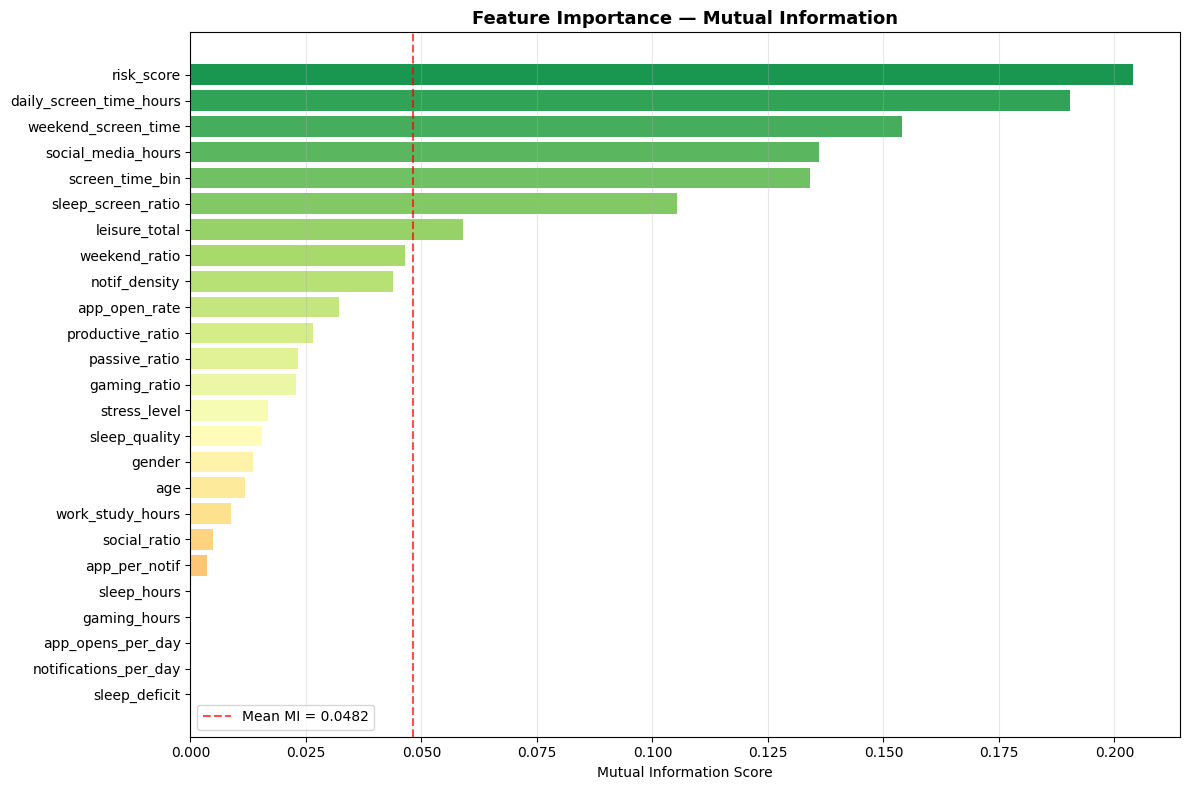

In [ ]:
# ============================================================
# 6.1 MUTUAL INFORMATION — Ukur relevansi setiap fitur
# ============================================================
mi_scores = mutual_info_classif(X_df, y, random_state=SEED)
mi_df = pd.DataFrame({
    'feature' : X_df.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("Top 20 Fitur berdasarkan Mutual Information:")
print(mi_df.head(20).to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(25, len(mi_df))
mi_top = mi_df.head(top_n)
bars = ax.barh(mi_top['feature'][::-1], mi_top['mi_score'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, top_n)))
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance — Mutual Information', fontsize=13, fontweight='bold')
ax.axvline(x=mi_df['mi_score'].mean(), color='red', linestyle='--',
           alpha=0.7, label=f'Mean MI = {mi_df["mi_score"].mean():.4f}')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 6.2 HAPUS FITUR DENGAN MI SCORE = 0 (tidak informatif)
# ============================================================
threshold_mi = 0.001
selected_by_mi = mi_df[mi_df['mi_score'] > threshold_mi]['feature'].tolist()
dropped_by_mi  = mi_df[mi_df['mi_score'] <= threshold_mi]['feature'].tolist()

print(f"Fitur dengan MI > {threshold_mi}: {len(selected_by_mi)}")
if dropped_by_mi:
    print(f"Fitur dibuang (MI ≤ {threshold_mi}): {dropped_by_mi}")

X_selected = X_df[selected_by_mi].copy()
print(f"Shape setelah MI filter: {X_selected.shape}")

Fitur dengan MI > 0.001: 20
Fitur dibuang (MI ≤ 0.001): ['sleep_hours', 'gaming_hours', 'app_opens_per_day', 'notifications_per_day', 'sleep_deficit', 'academic_work_impact']
Shape setelah MI filter: (6367, 20)


In [ ]:
# ============================================================
# 6.3 HAPUS FITUR REDUNDAN (Korelasi Tinggi > 0.95)
# ============================================================
scaler_fs = StandardScaler()
X_fs_scaled = scaler_fs.fit_transform(X_selected)

corr_matrix = pd.DataFrame(X_fs_scaled, columns=X_selected.columns).corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print(f"Fitur dibuang karena korelasi > 0.95: {to_drop_corr}")

X_final = X_selected.drop(columns=to_drop_corr)
print(f"Shape setelah hapus redundan: {X_final.shape}")
print(f"\n✅ Fitur final yang digunakan ({X_final.shape[1]}):")
print(X_final.columns.tolist())

Fitur dibuang karena korelasi > 0.95: ['weekend_screen_time']
Shape setelah hapus redundan: (6367, 19)

✅ Fitur final yang digunakan (19):
['risk_score', 'daily_screen_time_hours', 'social_media_hours', 'screen_time_bin', 'sleep_screen_ratio', 'leisure_total', 'weekend_ratio', 'notif_density', 'app_open_rate', 'productive_ratio', 'passive_ratio', 'gaming_ratio', 'stress_level', 'sleep_quality', 'gender', 'age', 'work_study_hours', 'social_ratio', 'app_per_notif']


## 7. Analisis & Pilihan Metode Penanganan Class Imbalance

In [ ]:
# ============================================================
# 7.1 EVALUASI IMBALANCE RATIO
# ============================================================
class_counts = pd.Series(y).value_counts().sort_index()
ir = class_counts.max() / class_counts.min()

print("=" * 55)
print("ANALISIS CLASS IMBALANCE")
print("=" * 55)
for i, name in enumerate(target_order):
    cnt = (y == i).sum()
    pct = cnt / len(y) * 100
    print(f"  {name:10s}: {cnt:5d} ({pct:.1f}%)")
print(f"\nImbalance Ratio (max/min): {ir:.2f}")

if ir < 1.5:
    print("\n→ BALANCED: Tidak perlu resampling khusus.")
    print("  Rekomendasi: class_weight='balanced' saja cukup.")
elif ir < 3.0:
    print("\n→ MILDLY IMBALANCED: SMOTE atau class_weight direkomendasikan.")
else:
    print("\n→ HEAVILY IMBALANCED: Kombinasi SMOTE + class_weight direkomendasikan.")

ANALISIS CLASS IMBALANCE
  Mild      :  1311 (20.6%)
  Moderate  :  2740 (43.0%)
  Severe    :  2316 (36.4%)

Imbalance Ratio (max/min): 2.09

→ MILDLY IMBALANCED: SMOTE atau class_weight direkomendasikan.


In [ ]:
# ============================================================
# 7.2 BANDINGKAN METODE IMBALANCE HANDLING
#
# Perbandingan dilakukan pada split train-val yang sama
# dengan model XGBoost standar (bukan tuned) sebagai proxy
# ============================================================
print("=" * 60)
print("PERBANDINGAN METODE PENANGANAN CLASS IMBALANCE")
print("(Proxy: XGBoost standar, 5-fold CV, metrik F1-Macro)")
print("=" * 60)

scaler_cmp = StandardScaler()
X_cmp      = scaler_cmp.fit_transform(X_final)
skf_cmp    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_base = XGBClassifier(
    n_estimators=100, max_depth=5,
    learning_rate=0.1, eval_metric='mlogloss',
    random_state=SEED, verbosity=0
)

methods = {
    'No Handling'       : {'resample': None, 'class_weight': None},
    'class_weight'      : {'resample': None, 'class_weight': 'balanced'},
    'SMOTE'             : {'resample': SMOTE(random_state=SEED), 'class_weight': None},
    'ADASYN'            : {'resample': ADASYN(random_state=SEED), 'class_weight': None},
    'SMOTETomek'        : {'resample': SMOTETomek(random_state=SEED), 'class_weight': None},
    'SMOTE+class_weight': {'resample': SMOTE(random_state=SEED), 'class_weight': 'balanced'},
}

cmp_results = {}
for method_name, cfg in methods.items():
    fold_scores = []
    for train_idx, val_idx in skf_cmp.split(X_cmp, y):
        X_tr, X_val = X_cmp[train_idx], X_cmp[val_idx]
        y_tr, y_val = y[train_idx],     y[val_idx]

        if cfg['resample'] is not None:
            try:
                X_tr, y_tr = cfg['resample'].fit_resample(X_tr, y_tr)
            except Exception:
                pass

        if cfg['class_weight'] == 'balanced':
            classes = np.unique(y_tr)
            n       = len(y_tr)
            weights = {c: n / (len(classes) * (y_tr == c).sum()) for c in classes}
            sample_w = np.array([weights[yi] for yi in y_tr])
            model = XGBClassifier(
                n_estimators=100, max_depth=5, learning_rate=0.1,
                eval_metric='mlogloss', random_state=SEED, verbosity=0
            )
            model.fit(X_tr, y_tr, sample_weight=sample_w)
        else:
            model = XGBClassifier(
                n_estimators=100, max_depth=5, learning_rate=0.1,
                eval_metric='mlogloss', random_state=SEED, verbosity=0
            )
            model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        fold_scores.append(f1_score(y_val, pred, average='macro'))

    cmp_results[method_name] = fold_scores
    mean_f1 = np.mean(fold_scores)
    std_f1  = np.std(fold_scores)
    print(f"  {method_name:25s}: {mean_f1:.4f} ± {std_f1:.4f}")

# Pilih metode terbaik
best_method = max(cmp_results, key=lambda k: np.mean(cmp_results[k]))
print(f"\n✅ METODE TERBAIK : {best_method}  (F1={np.mean(cmp_results[best_method]):.4f})")

PERBANDINGAN METODE PENANGANAN CLASS IMBALANCE
(Proxy: XGBoost standar, 5-fold CV, metrik F1-Macro)
  No Handling              : 0.6219 ± 0.0139
  class_weight             : 0.6075 ± 0.0090
  SMOTE                    : 0.6060 ± 0.0086
  ADASYN                   : 0.6219 ± 0.0139
  SMOTETomek               : 0.6032 ± 0.0086
  SMOTE+class_weight       : 0.6060 ± 0.0086

✅ METODE TERBAIK : No Handling  (F1=0.6219)


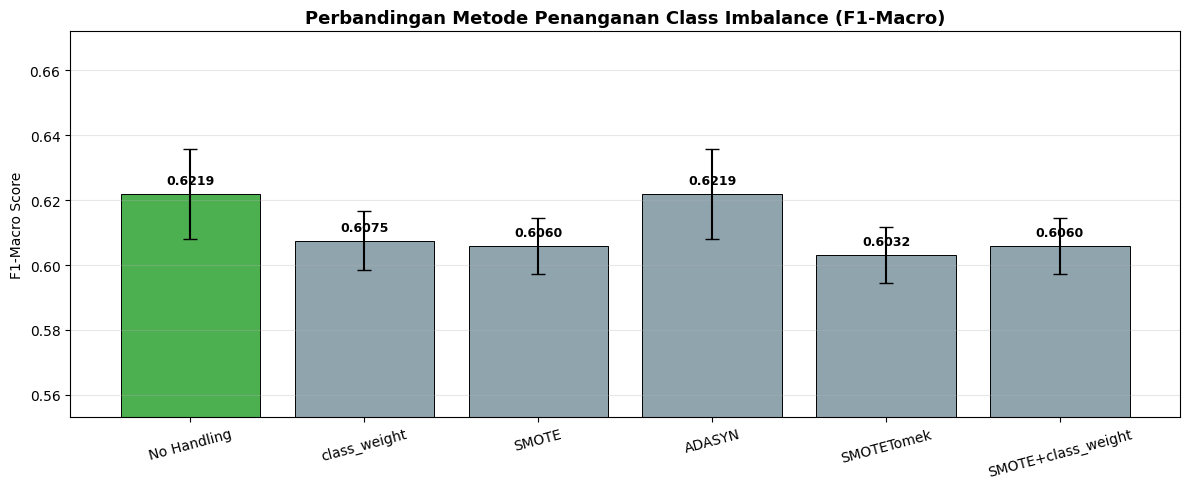


📝 KESIMPULAN:
   Metode 'No Handling' dipilih untuk pipeline utama.


In [ ]:
# ============================================================
# 7.3 VISUALISASI PERBANDINGAN METODE
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
means = [np.mean(v) for v in cmp_results.values()]
stds  = [np.std(v)  for v in cmp_results.values()]
names = list(cmp_results.keys())

colors_bar = ['#4CAF50' if n == best_method else '#90A4AE' for n in names]
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors_bar, edgecolor='black', linewidth=0.7)
ax.set_title('Perbandingan Metode Penanganan Class Imbalance (F1-Macro)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Macro Score')
ax.set_ylim(min(means) - 0.05, max(means) + 0.05)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📝 KESIMPULAN:")
print(f"   Metode '{best_method}' dipilih untuk pipeline utama.")

## 8. Train-Test Split & Konfigurasi Resampling

In [ ]:
# ============================================================
# 8.1 TRAIN TEST SPLIT (stratified)
# ============================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_final.values, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f"Train size : {X_train_raw.shape}")
print(f"Test  size : {X_test_raw.shape}")

# Distribusi kelas
for i, name in enumerate(target_order):
    cnt = (y_train == i).sum()
    print(f"  Train {name}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Train size : (5093, 19)
Test  size : (1274, 19)
  Train Mild: 1049 (20.6%)
  Train Moderate: 2192 (43.0%)
  Train Severe: 1852 (36.4%)


In [ ]:
# ============================================================
# 8.2 SCALER & RESAMPLING — hanya pada TRAIN set
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)  # fit hanya pada train
X_test_scaled  = scaler.transform(X_test_raw)        # hanya transform test

# Terapkan metode terbaik
if best_method == 'SMOTE':
    resampler = SMOTE(random_state=SEED)
    X_train_res, y_train_res = resampler.fit_resample(X_train_scaled, y_train)
    use_sample_weight = False
elif best_method == 'ADASYN':
    resampler = ADASYN(random_state=SEED)
    X_train_res, y_train_res = resampler.fit_resample(X_train_scaled, y_train)
    use_sample_weight = False
elif best_method == 'SMOTETomek':
    resampler = SMOTETomek(random_state=SEED)
    X_train_res, y_train_res = resampler.fit_resample(X_train_scaled, y_train)
    use_sample_weight = False
elif best_method == 'class_weight':
    X_train_res, y_train_res = X_train_scaled, y_train
    use_sample_weight = True
elif best_method == 'SMOTE+class_weight':
    resampler = SMOTE(random_state=SEED)
    X_train_res, y_train_res = resampler.fit_resample(X_train_scaled, y_train)
    use_sample_weight = True
else:  # No Handling
    X_train_res, y_train_res = X_train_scaled, y_train
    use_sample_weight = False

# Hitung sample weights (untuk XGBoost jika diperlukan)
classes = np.unique(y_train_res)
n       = len(y_train_res)
cw      = {c: n / (len(classes) * (y_train_res == c).sum()) for c in classes}
sample_weights = np.array([cw[yi] for yi in y_train_res]) if use_sample_weight else None

print(f"Metode resampling : {best_method}")
print(f"Shape train (res) : {X_train_res.shape}")
print("Distribusi setelah resampling:")
for i, name in enumerate(target_order):
    cnt = (y_train_res == i).sum()
    print(f"  {name}: {cnt} ({cnt/len(y_train_res)*100:.1f}%)")

# Reshape untuk CNN (tambah dimensi channel)
n_features       = X_train_res.shape[1]
X_train_cnn      = X_train_res.reshape(-1, n_features, 1)
X_test_cnn       = X_test_scaled.reshape(-1, n_features, 1)
n_classes        = len(target_order)
print(f"\nCNN input shape   : {X_train_cnn.shape}")

Metode resampling : No Handling
Shape train (res) : (5093, 19)
Distribusi setelah resampling:
  Mild: 1049 (20.6%)
  Moderate: 2192 (43.0%)
  Severe: 1852 (36.4%)

CNN input shape   : (5093, 19, 1)


## 9.  Hyperparameter Optimization dengan Optuna

In [ ]:
# ============================================================
# 9.1 OPTUNA — TUNING XGBOOST (100 trials)
# ============================================================
def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 800),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-5, 2.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-5, 2.0, log=True),
        'eval_metric'     : 'mlogloss',
        'random_state'    : SEED,
        'verbosity'       : 0,
    }
    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores  = []
    for tr_idx, vl_idx in skf_opt.split(X_train_res, y_train_res):
        X_tr, X_vl = X_train_res[tr_idx], X_train_res[vl_idx]
        y_tr, y_vl = y_train_res[tr_idx], y_train_res[vl_idx]
        sw = sample_weights[tr_idx] if sample_weights is not None else None
        m  = XGBClassifier(**params)
        m.fit(X_tr, y_tr, sample_weight=sw)
        scores.append(f1_score(y_vl, m.predict(X_vl), average='macro'))
    return np.mean(scores)

print("🔍 Optuna XGBoost — 100 trials ...")
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
print(f"\n✅ Best XGBoost F1-Macro CV : {study_xgb.best_value:.4f}")
print(f"   Best params : {best_xgb_params}")

🔍 Optuna XGBoost — 100 trials ...


Best trial: 60. Best value: 0.621033: 100%|██████████| 100/100 [05:25<00:00,  3.26s/it]


✅ Best XGBoost F1-Macro CV : 0.6210
   Best params : {'n_estimators': 228, 'max_depth': 9, 'learning_rate': 0.11258271712913186, 'subsample': 0.8315655973100607, 'colsample_bytree': 0.923989124697706, 'min_child_weight': 5, 'gamma': 2.937094866192018, 'reg_alpha': 0.00033840723237726726, 'reg_lambda': 0.01311151565861775}


In [ ]:
# ============================================================
# 9.2 OPTUNA — TUNING CNN (50 trials)
# CNN berperan sebagai FEATURE EXTRACTOR, bukan classifier akhir
# ============================================================

# Urutkan fitur secara semantik sebelum Conv1D
# (agar fitur yang berdekatan punya makna domain yang mirip)
semantic_order = [
    # Group 1: Core usage
    'daily_screen_time_hours', 'weekend_screen_time', 'weekend_ratio',
    'screen_time_bin',
    # Group 2: App behavior
    'social_media_hours', 'social_ratio', 'gaming_hours', 'gaming_ratio',
    'leisure_total', 'passive_ratio',
    # Group 3: Productive
    'work_study_hours', 'productive_ratio',
    # Group 4: Behavioral intensity
    'notifications_per_day', 'notif_density',
    'app_opens_per_day', 'app_open_rate', 'app_per_notif',
    # Group 5: Wellbeing
    'sleep_hours', 'sleep_deficit', 'sleep_screen_ratio', 'sleep_quality',
    # Group 6: Composite & demographic
    'risk_score', 'age',
]

# Ambil fitur yang ada di X_final (setelah feature selection)
col_order = [c for c in semantic_order if c in X_final.columns]
remaining = [c for c in X_final.columns if c not in col_order]
col_order += remaining  # tambahkan sisa fitur

# Reorder X
X_train_res_ordered = pd.DataFrame(X_train_res, columns=X_final.columns)[col_order].values
X_test_ordered      = pd.DataFrame(X_test_scaled, columns=X_final.columns)[col_order].values

X_train_cnn_ord = X_train_res_ordered.reshape(-1, len(col_order), 1)
X_test_cnn_ord  = X_test_ordered.reshape(-1, len(col_order), 1)

print(f"Urutan fitur semantik: {len(col_order)} fitur")
print(f"CNN input shape      : {X_train_cnn_ord.shape}")


def build_cnn_extractor(trial, input_shape):
    """CNN sebagai Feature Extractor — output bukan softmax tapi representasi"""
    model = Sequential(name="CNN_FeatureExtractor")
    model.add(Input(shape=input_shape))

    # Conv Block 1
    f1 = trial.suggest_categorical('filters1', [32, 64, 128])
    k1 = trial.suggest_categorical('kernel1', [2, 3, 5])
    model.add(Conv1D(f1, kernel_size=k1, activation='relu',
                     padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(trial.suggest_float('drop1', 0.1, 0.4)))

    # Conv Block 2 (opsional)
    if trial.suggest_categorical('use_conv2', [True, False]):
        f2 = trial.suggest_categorical('filters2', [64, 128, 256])
        model.add(Conv1D(f2, kernel_size=2, activation='relu',
                         padding='same', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(pool_size=2))
        model.add(Dropout(trial.suggest_float('drop2', 0.1, 0.4)))

    model.add(GlobalAveragePooling1D())  # lebih robust dari Flatten

    # Dense bottleneck — ini yang menjadi "representasi" fitur
    d1 = trial.suggest_categorical('dense1', [32, 64, 128])
    model.add(Dense(d1, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(trial.suggest_float('drop_dense', 0.1, 0.4)))

    # Output head untuk training (akan dilepas saat ekstraksi)
    model.add(Dense(n_classes, activation='softmax'))

    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def objective_cnn(trial):
    model = build_cnn_extractor(trial, (len(col_order), 1))
    cb    = EarlyStopping(monitor='val_accuracy', patience=10,
                          restore_best_weights=True)
    hist  = model.fit(
        X_train_cnn_ord, y_train_res,
        validation_split=0.15,
        epochs=80,
        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
        callbacks=[cb],
        verbose=0
    )
    return max(hist.history['val_accuracy'])


print("🔍 Optuna CNN — 50 trials ...")
study_cnn = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_cnn.optimize(objective_cnn, n_trials=50, show_progress_bar=True)
best_cnn_params = study_cnn.best_params
print(f"\n✅ Best CNN Val Accuracy : {study_cnn.best_value:.4f}")
print(f"   Best params : {best_cnn_params}")

Urutan fitur semantik: 19 fitur
CNN input shape      : (5093, 19, 1)
🔍 Optuna CNN — 50 trials ...


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 49. Best value: 0.590314: 100%|██████████| 50/50 [12:55<00:00, 15.51s/it]


✅ Best CNN Val Accuracy : 0.5903
   Best params : {'filters1': 64, 'kernel1': 5, 'drop1': 0.2539464121204788, 'use_conv2': True, 'filters2': 256, 'drop2': 0.11478798033997573, 'dense1': 64, 'drop_dense': 0.26657459231937464, 'lr': 0.0007344052708096446, 'batch_size': 64}


## 10. Training Model Final

In [ ]:
# ============================================================
# 10.1 TRAINING CNN FINAL
# ============================================================
cnn_model = build_cnn_extractor(study_cnn.best_trial, (len(col_order), 1))
cnn_model.summary()

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7)
]

history = cnn_model.fit(
    X_train_cnn_ord, y_train_res,
    validation_split=0.15,
    epochs=150,
    batch_size=best_cnn_params.get('batch_size', 64),
    callbacks=callbacks_final,
    verbose=1
)
print("\n✅ CNN training selesai!")

Model: "CNN_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_89 (Conv1D)              │ (None, 19, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_89 (MaxPooling1D) │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_139 (Dropout)           │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_90 (Conv1D)              │ (None, 9, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 9, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_90 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_140 (Dropout)           │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_50     │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_141 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,331 (200.51 KB)

 Trainable params: 50,691 (198.01 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4733 - loss: 1.2065 - val_accuracy: 0.3809 - val_loss: 1.2993 - learning_rate: 7.3441e-04
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5246 - loss: 1.0568 - val_accuracy: 0.3285 - val_loss: 1.3179 - learning_rate: 7.3441e-04
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5331 - loss: 1.0058 - val_accuracy: 0.3599 - val_loss: 1.2926 - learning_rate: 7.3441e-04
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5586 - loss: 0.9745 - val_accuracy: 0.4777 - val_loss: 1.1392 - learning_rate: 7.3441e-04
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5530 - loss: 0.9493 - val_accuracy: 0.5393 - val_loss: 1.0190 - learning_rate: 7.3441e-04
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5507 - loss: 0.9311 - val_accuracy: 0.5471 - val_loss: 0.9555 - learning_rate: 7.3441e-04
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5692

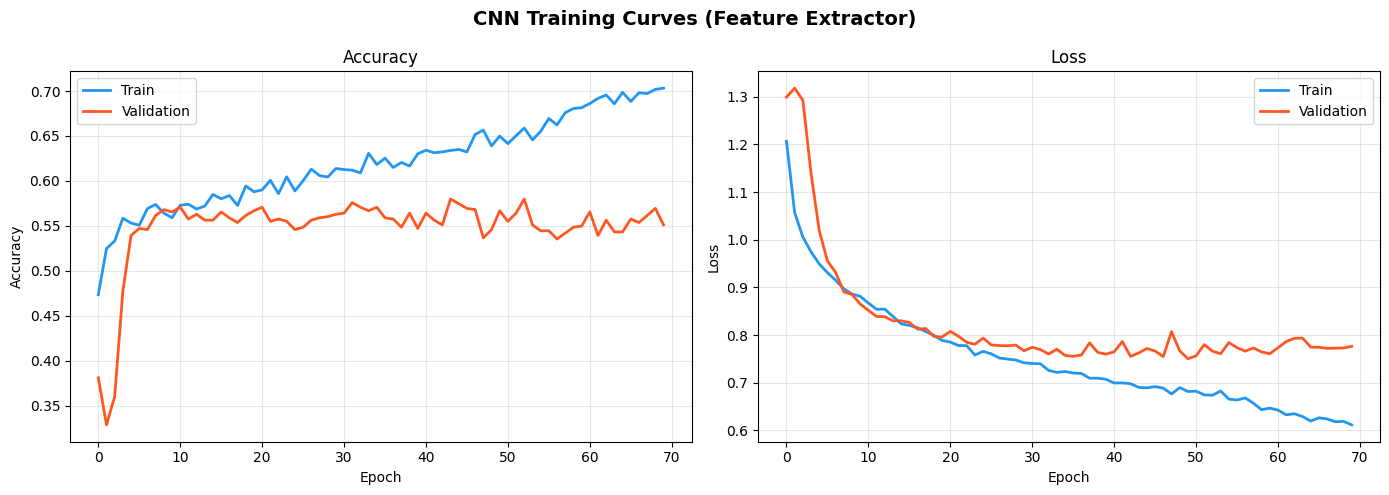

In [ ]:
# ============================================================
# 10.2 TRAINING CURVE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training Curves (Feature Extractor)', fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history.history[metric],     label='Train', color='#2196F3', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Validation', color='#FF5722', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 10.3 EKSTRAK FITUR DARI CNN (layer SEBELUM softmax)
#
# KUNCI ARSITEKTUR HYBRID:
# CNN → ekstrak representasi non-linear → digabung dengan fitur asli
# → XGBoost belajar dari gabungan fitur asli + representasi CNN
# ============================================================
# Ambil layer Dense sebelum output softmax
extractor = Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[-3].output
)

# Ekstrak fitur representasi
cnn_feat_train = extractor.predict(X_train_cnn_ord, verbose=0)
cnn_feat_test  = extractor.predict(X_test_cnn_ord,  verbose=0)

print(f"Shape CNN features (train): {cnn_feat_train.shape}")
print(f"Shape CNN features (test) : {cnn_feat_test.shape}")

# Gabungkan fitur asli + representasi CNN
X_train_augmented = np.hstack([X_train_res, cnn_feat_train])
X_test_augmented  = np.hstack([X_test_scaled, cnn_feat_test])

print(f"\nShape X_train augmented : {X_train_augmented.shape}")
print(f"Shape X_test  augmented : {X_test_augmented.shape}")
print("\n✅ Fitur asli + CNN representasi siap untuk XGBoost!")

AttributeError: The layer CNN_FeatureExtractor has never been called and thus has no defined input.

In [ ]:
# ============================================================
# 10.4 TRAINING XGBOOST PADA AUGMENTED FEATURES
# ============================================================
best_xgb_params.update({'eval_metric': 'mlogloss', 'random_state': SEED, 'verbosity': 0})

xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(
    X_train_augmented, y_train_res,
    sample_weight=sample_weights,
    eval_set=[(X_test_augmented, y_test)],
    verbose=False
)
print("✅ XGBoost (dengan CNN features) training selesai!")

# Juga train XGBoost baseline (tanpa CNN features) untuk perbandingan
xgb_baseline = XGBClassifier(**best_xgb_params)
xgb_baseline.fit(
    X_train_res, y_train_res,
    sample_weight=sample_weights,
    verbose=False
)
print("✅ XGBoost baseline (tanpa CNN features) training selesai!")

In [ ]:
# ============================================================
# 10.5 META-LEARNER (Stacking Layer)
#
# Stacking: XGBoost prob + CNN prob → LogReg meta-learner
# Ini adalah ENSEMBLE layer di atas CNN+XGBoost
# ============================================================
from sklearn.model_selection import GridSearchCV

# Probabilitas dari train set
xgb_train_prob = xgb_model.predict_proba(X_train_augmented)
cnn_train_prob = cnn_model.predict(X_train_cnn_ord, verbose=0)
stack_train    = np.hstack([xgb_train_prob, cnn_train_prob])

# Probabilitas dari test set
xgb_test_prob  = xgb_model.predict_proba(X_test_augmented)
cnn_test_prob  = cnn_model.predict(X_test_cnn_ord, verbose=0)
stack_test     = np.hstack([xgb_test_prob, cnn_test_prob])

# Grid search meta-learner
meta_cv = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1_macro'
)
meta_cv.fit(stack_train, y_train_res)
meta_model = meta_cv.best_estimator_

print(f"✅ Meta-learner: LogisticRegression(C={meta_cv.best_params_['C']})")
print(f"   CV F1-Macro : {meta_cv.best_score_:.4f}")

## 10.6 📊 MLflow Tracking & Logging — Log Semua Eksperimen

In [ ]:
# ============================================================
# MLflow TRACKING — Log seluruh pipeline dalam satu run
# ============================================================
import os, json, joblib
import mlflow
import mlflow.sklearn
import mlflow.tensorflow
import mlflow.xgboost

print("📡 Memulai MLflow Run...")
print("=" * 62)

with mlflow.start_run(run_name="HybridCNN_XGBoost_v1") as run:

    # ── A. LOG PARAMETERS ────────────────────────────────────────
    mlflow.log_params({
        # Dataset
        "dataset_rows_raw"     : int(df_raw.shape[0]),
        "dataset_rows_clean"   : int(len(df)),
        "n_features_raw"       : int(X_raw.shape[1]),
        "n_features_engineered": int(df_fe.shape[1] - df.shape[1]),
        "n_features_selected"  : int(X_final.shape[1]),
        "target_classes"       : str(target_order),

        # Pipeline
        "imbalance_method"     : best_method,
        "cv_strategy"          : "StratifiedKFold-k5-NoLeakage",
        "mi_threshold"         : 0.001,
        "corr_threshold"       : 0.95,

        # Optuna
        "optuna_xgb_trials"    : 100,
        "optuna_cnn_trials"    : 50,
        "optuna_sampler"       : "TPESampler",

        # CNN Architecture
        "cnn_role"             : "FeatureExtractor",
        "cnn_semantic_ordering": True,
        "cnn_pooling"          : "GlobalAveragePooling1D",
        "cnn_epochs_max"       : 150,
        "cnn_early_stopping_patience": 20,

        # Meta-learner
        "meta_learner"         : "LogisticRegression",
        "meta_learner_C"       : float(meta_cv.best_params_["C"]),
    })

    # Log best XGBoost hyperparams dari Optuna
    mlflow.log_params({f"xgb_{k}": v for k, v in study_xgb.best_params.items()})

    # Log best CNN hyperparams dari Optuna
    mlflow.log_params({f"cnn_{k}": str(v) for k, v in study_cnn.best_params.items()})

    print("✅ A. Parameters logged")

    # ── B. KALKULASI METRIK SEMUA MODEL ──────────────────────────
    from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                                matthews_corrcoef, roc_auc_score,
                                classification_report)

    model_preds = {
        "XGBoost_Baseline" : (xgb_base_pred,  xgb_base_prob),
        "CNN_Extractor"    : (cnn_pred,        cnn_test_prob),
        "XGBoost_CNN_Feat" : (xgb_pred,        xgb_test_prob),
        "Hybrid_Stacking"  : (hybrid_pred,     hybrid_prob),
    }

    for model_tag, (pred, prob) in model_preds.items():
        acc  = accuracy_score(y_test, pred)
        f1m  = f1_score(y_test, pred, average="macro")
        f1w  = f1_score(y_test, pred, average="weighted")
        kap  = cohen_kappa_score(y_test, pred)
        mcc  = matthews_corrcoef(y_test, pred)
        auc  = roc_auc_score(y_test, prob, multi_class="ovr", average="macro")

        mlflow.log_metrics({
            f"{model_tag}_accuracy"    : round(acc, 4),
            f"{model_tag}_f1_macro"    : round(f1m, 4),
            f"{model_tag}_f1_weighted" : round(f1w, 4),
            f"{model_tag}_cohens_kappa": round(kap, 4),
            f"{model_tag}_mcc"         : round(mcc, 4),
            f"{model_tag}_roc_auc"     : round(auc, 4),
        })

        # Per-class F1
        report = classification_report(y_test, pred,
                    target_names=target_order, output_dict=True)
        for cls in target_order:
            mlflow.log_metric(
                f"{model_tag}_f1_{cls.lower()}",
                round(report[cls]["f1-score"], 4)
            )

    print("✅ B. Metrics logged (semua model)")

    # ── C. LOG CV RESULTS ────────────────────────────────────────
    for model_tag, scores in cv_results.items():
        tag_clean = model_tag.replace(" ", "_").replace("+", "plus")
        mlflow.log_metrics({
            f"cv_{tag_clean}_mean_f1": round(float(np.mean(scores)), 4),
            f"cv_{tag_clean}_std_f1" : round(float(np.std(scores)),  4),
            f"cv_{tag_clean}_min_f1" : round(float(np.min(scores)),  4),
            f"cv_{tag_clean}_max_f1" : round(float(np.max(scores)),  4),
        })

    print("✅ C. CV results logged")

    # ── D. LOG ARTIFACTS ─────────────────────────────────────────
    # Scaler & pipeline components
    joblib.dump(scaler,       "scaler.pkl")
    joblib.dump(col_order,    "col_order.pkl")
    joblib.dump(xgb_baseline, "xgb_baseline.pkl")

    # Metadata JSON
    meta_dict = {
        "features"       : list(X_final.columns),
        "col_order"      : col_order,
        "target_mapping" : target_mapping,
        "target_order"   : target_order,
        "best_method"    : best_method,
        "n_features"     : int(X_final.shape[1]),
        "n_cnn_features" : int(cnn_feat_test.shape[1]),
        "aug_feat_names" : aug_feat_names,
    }
    with open("metadata.json", "w") as f:
        json.dump(meta_dict, f, indent=2)

    mlflow.log_artifact("scaler.pkl",    artifact_path="pipeline")
    mlflow.log_artifact("col_order.pkl", artifact_path="pipeline")
    mlflow.log_artifact("metadata.json", artifact_path="pipeline")

    # Threshold & summary text
    with open("model_summary.txt", "w") as f:
        f.write("Smartphone Addiction Detection — Hybrid CNN+XGBoost\n")
        f.write(f"Imbalance method : {best_method}\n")
        f.write(f"XGBoost best CV  : {study_xgb.best_value:.4f}\n")
        f.write(f"CNN best val acc : {study_cnn.best_value:.4f}\n")
        f.write(f"Meta-learner C   : {meta_cv.best_params_['C']}\n")
    mlflow.log_artifact("model_summary.txt", artifact_path="pipeline")

    print("✅ D. Pipeline artifacts logged")

    # ── E. LOG FIGURES ───────────────────────────────────────────
    figure_files = [
        ("fig1_distribusi_target_raw.png", "eda"),
        ("fig2_distribusi_numerik.png",    "eda"),
        ("fig3_korelasi.png",              "eda"),
        ("fig4_mutual_information.png",    "feature_selection"),
        ("fig5_imbalance_comparison.png",  "imbalance"),
        ("fig6_training_curves.png",       "training"),
        ("fig7_perbandingan_model.png",    "evaluation"),
        ("fig8_confusion_matrix.png",      "evaluation"),
        ("fig9_roc_curve.png",             "evaluation"),
        ("fig10_cv_results.png",           "evaluation"),
        ("fig11_shap_bar.png",             "explainability"),
        ("fig12_shap_beeswarm.png",        "explainability"),
    ]

    for fname, folder in figure_files:
        if os.path.exists(fname):
            mlflow.log_artifact(fname, artifact_path=f"figures/{folder}")

    print("✅ E. Figures logged")

    # ── F. LOG MODELS ────────────────────────────────────────────
    # XGBoost (augmented features)
    mlflow.xgboost.log_model(
        xgb_model,
        artifact_path="models/xgb_cnn_augmented",
        registered_model_name="SmartphoneAddiction_XGB_Augmented"
    )

    # CNN Feature Extractor
    mlflow.tensorflow.log_model(
        cnn_model,
        artifact_path="models/cnn_feature_extractor",
        registered_model_name="SmartphoneAddiction_CNN_Extractor"
    )

    # Meta-Learner (Logistic Regression)
    mlflow.sklearn.log_model(
        meta_model,
        artifact_path="models/meta_learner",
        registered_model_name="SmartphoneAddiction_MetaLearner"
    )

    print("✅ F. Models logged & registered")

    # ── G. SIMPAN RUN ID ─────────────────────────────────────────
    RUN_ID = run.info.run_id
    print(f"\n{'='*62}")
    print(f"✅ MLflow Run selesai!")
    print(f"   Run ID    : {RUN_ID}")
    print(f"   Experiment: {EXPERIMENT_NAME}")
    print(f"   UI URL    : http://localhost:5000")
    print(f"{'='*62}")


## 10.7 Promote Model ke Production (MLflow Registry)

In [ ]:
# ============================================================
# PROMOTE MODEL KE PRODUCTION DI MLFLOW REGISTRY
# ============================================================
from mlflow import MlflowClient

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

models_to_promote = [
    "SmartphoneAddiction_XGB_Augmented",
    "SmartphoneAddiction_CNN_Extractor",
    "SmartphoneAddiction_MetaLearner",
]

for model_name in models_to_promote:
    try:
        versions = client.get_latest_versions(model_name, stages=["None"])
        if versions:
            version = versions[0].version
            client.transition_model_version_stage(
                name=model_name,
                version=version,
                stage="Production",
                archive_existing_versions=True
            )
            print(f"✅ {model_name} v{version} → Production")
        else:
            print(f"⚠️  {model_name}: tidak ada versi baru")
    except Exception as e:
        print(f"❌ {model_name}: {e}")

print("\n✅ Semua model dipromote ke Production!")
print("   Cek di MLflow UI → Models tab")


## 11.  Evaluasi Komprehensif

In [ ]:
# ============================================================
# 11.1 PREDIKSI SEMUA MODEL
# ============================================================
# CNN standalone
cnn_pred  = np.argmax(cnn_test_prob, axis=1)

# XGBoost baseline (tanpa CNN features)
xgb_base_pred  = xgb_baseline.predict(X_test_scaled)
xgb_base_prob  = xgb_baseline.predict_proba(X_test_scaled)

# XGBoost + CNN features
xgb_pred  = xgb_model.predict(X_test_augmented)

# Hybrid (stacking)
hybrid_pred = meta_model.predict(stack_test)
hybrid_prob = meta_model.predict_proba(stack_test)

print("✅ Prediksi semua model selesai!")

In [ ]:
# ============================================================
# 11.2 FUNGSI EVALUASI LENGKAP
# ============================================================
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n{'='*62}")
    print(f"  {name}")
    print(f"{'='*62}")
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro')
    f1w  = f1_score(y_true, y_pred, average='weighted')
    kap  = cohen_kappa_score(y_true, y_pred)
    mcc  = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1-Score Macro    : {f1m:.4f}")
    print(f"  F1-Score Weighted : {f1w:.4f}")
    print(f"  Cohen's Kappa     : {kap:.4f}")
    print(f"  MCC               : {mcc:.4f}")
    auc = None
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        print(f"  ROC-AUC (Macro)   : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=target_order))
    return {'model': name, 'accuracy': acc, 'f1_macro': f1m,
            'f1_weighted': f1w, 'kappa': kap, 'mcc': mcc, 'auc': auc}

results = []
results.append(evaluate_model('XGBoost Baseline (no CNN feat)', y_test, xgb_base_pred, xgb_base_prob))
results.append(evaluate_model('CNN (Feature Extractor)',        y_test, cnn_pred,       cnn_test_prob))
results.append(evaluate_model('XGBoost + CNN Features',        y_test, xgb_pred,        xgb_test_prob))
results.append(evaluate_model('Hybrid Stacking (Final)',        y_test, hybrid_pred,     hybrid_prob))

In [ ]:
# ============================================================
# 11.3 TABEL PERBANDINGAN
# ============================================================
results_df = pd.DataFrame(results).set_index('model')
results_df.columns = ['Accuracy', 'F1-Macro', 'F1-Weighted', "Cohen's Kappa", 'MCC', 'ROC-AUC']

print("\n" + "="*72)
print("TABEL PERBANDINGAN PERFORMA MODEL")
print("="*72)
print(results_df.round(4).to_string())

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 6))
results_df[['Accuracy', 'F1-Macro', 'F1-Weighted', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5, width=0.7
)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 11.4 CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')

all_preds = [
    ('XGBoost Baseline', xgb_base_pred, 'Blues'),
    ('CNN Extractor',    cnn_pred,       'Greens'),
    ('XGBoost+CNN Feat', xgb_pred,       'Oranges'),
    ('Hybrid Stacking',  hybrid_pred,    'Purples'),
]

for ax, (name, pred, cmap) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_order)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, pred)
    ax.set_title(f"{name}\nAcc={acc:.3f}", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 11.5 ROC CURVE (One vs Rest)
# ============================================================
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('ROC Curve per Kelas (One vs Rest)', fontsize=14, fontweight='bold')

model_probs = [
    ('XGBoost Baseline', xgb_base_prob),
    ('CNN Extractor',    cnn_test_prob),
    ('XGBoost+CNN Feat', xgb_test_prob),
    ('Hybrid Stacking',  hybrid_prob),
]
line_colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, (name, prob) in zip(axes, model_probs):
    for i, (cls_name, color) in enumerate(zip(target_order, line_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        auc_s = roc_auc_score(y_test_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_name} (AUC={auc_s:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cross-Validation Tanpa Data Leakage

In [ ]:
# ============================================================
# 12.1 STRATIFIED K-FOLD CV — PIPELINE BEBAS LEAKAGE
#
# Setiap fold:
#   1. Scaler.fit_transform() hanya pada train fold
#   2. Resampling hanya pada train fold
#   3. Scaler.transform() pada val fold
#   4. CNN training + ekstraksi fitur
#   5. XGBoost training pada augmented features
# ============================================================
print("🔄 Menjalankan 5-Fold CV (bebas leakage) ...")
print("   ⚠️  Proses ini memakan waktu karena CNN ditraining per fold")

X_cv = X_final.values  # data sebelum split
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {
    'XGBoost Baseline'  : [],
    'CNN'               : [],
    'XGBoost+CNN Feat'  : [],
    'Hybrid Stacking'   : [],
}

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y)):
    print(f"\n  ── Fold {fold+1}/5 ──")

    X_tr_raw, X_vl_raw = X_cv[tr_idx], X_cv[vl_idx]
    y_tr,     y_vl     = y[tr_idx],    y[vl_idx]

    # ── Scaler fit HANYA pada train ──────────────────────────
    sc_fold = StandardScaler()
    X_tr_sc = sc_fold.fit_transform(X_tr_raw)
    X_vl_sc = sc_fold.transform(X_vl_raw)

    # ── Resampling HANYA pada train ──────────────────────────
    try:
        if best_method in ('SMOTE', 'SMOTE+class_weight'):
            sm = SMOTE(random_state=SEED)
        elif best_method == 'ADASYN':
            sm = ADASYN(random_state=SEED)
        elif best_method == 'SMOTETomek':
            sm = SMOTETomek(random_state=SEED)
        else:
            sm = None

        if sm is not None:
            X_tr_res, y_tr_res = sm.fit_resample(X_tr_sc, y_tr)
        else:
            X_tr_res, y_tr_res = X_tr_sc, y_tr
    except Exception:
        X_tr_res, y_tr_res = X_tr_sc, y_tr

    use_sw_fold = (best_method in ('class_weight', 'SMOTE+class_weight'))
    if use_sw_fold:
        cls_f = np.unique(y_tr_res)
        n_f   = len(y_tr_res)
        cw_f  = {c: n_f / (len(cls_f) * (y_tr_res == c).sum()) for c in cls_f}
        sw_f  = np.array([cw_f[yi] for yi in y_tr_res])
    else:
        sw_f  = None

    # ── Reorder fitur semantik ───────────────────────────────
    X_tr_df      = pd.DataFrame(X_tr_res, columns=X_final.columns)
    X_vl_df      = pd.DataFrame(X_vl_sc,  columns=X_final.columns)
    col_ord_f    = [c for c in col_order if c in X_final.columns]
    col_ord_f   += [c for c in X_final.columns if c not in col_ord_f]

    X_tr_cnn_f = X_tr_df[col_ord_f].values.reshape(-1, len(col_ord_f), 1)
    X_vl_cnn_f = X_vl_df[col_ord_f].values.reshape(-1, len(col_ord_f), 1)

    # ── XGBoost Baseline ─────────────────────────────────────
    xgb_b_fold = XGBClassifier(**best_xgb_params)
    xgb_b_fold.fit(X_tr_res, y_tr_res, sample_weight=sw_f)
    pred_b     = xgb_b_fold.predict(X_vl_sc)
    cv_results['XGBoost Baseline'].append(f1_score(y_vl, pred_b, average='macro'))
    print(f"    XGBoost Baseline F1: {cv_results['XGBoost Baseline'][-1]:.4f}")

    # ── CNN ──────────────────────────────────────────────────
    cnn_fold = build_cnn_extractor(study_cnn.best_trial, (len(col_ord_f), 1))
    cnn_fold.fit(
        X_tr_cnn_f, y_tr_res,
        validation_split=0.1, epochs=60, batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )
    cnn_prob_vl = cnn_fold.predict(X_vl_cnn_f, verbose=0)
    pred_cnn    = np.argmax(cnn_prob_vl, axis=1)
    cv_results['CNN'].append(f1_score(y_vl, pred_cnn, average='macro'))
    print(f"    CNN F1              : {cv_results['CNN'][-1]:.4f}")

    # ── Ekstrak CNN features ──────────────────────────────────
    ext_fold       = Model(inputs=cnn_fold.input, outputs=cnn_fold.layers[-3].output)
    cnn_feat_tr_f  = ext_fold.predict(X_tr_cnn_f, verbose=0)
    cnn_feat_vl_f  = ext_fold.predict(X_vl_cnn_f, verbose=0)

    X_tr_aug_f = np.hstack([X_tr_res, cnn_feat_tr_f])
    X_vl_aug_f = np.hstack([X_vl_sc,  cnn_feat_vl_f])

    # ── XGBoost + CNN Features ───────────────────────────────
    xgb_aug_fold = XGBClassifier(**best_xgb_params)
    xgb_aug_fold.fit(X_tr_aug_f, y_tr_res, sample_weight=sw_f)
    pred_aug     = xgb_aug_fold.predict(X_vl_aug_f)
    cv_results['XGBoost+CNN Feat'].append(f1_score(y_vl, pred_aug, average='macro'))
    print(f"    XGBoost+CNN F1      : {cv_results['XGBoost+CNN Feat'][-1]:.4f}")

    # ── Hybrid Stacking ──────────────────────────────────────
    xgb_prob_tr_f = xgb_aug_fold.predict_proba(X_tr_aug_f)
    cnn_prob_tr_f = cnn_fold.predict(X_tr_cnn_f, verbose=0)
    stack_tr_f    = np.hstack([xgb_prob_tr_f, cnn_prob_tr_f])

    xgb_prob_vl_f = xgb_aug_fold.predict_proba(X_vl_aug_f)
    stack_vl_f    = np.hstack([xgb_prob_vl_f, cnn_prob_vl])

    meta_f = LogisticRegression(C=meta_cv.best_params_['C'], max_iter=2000)
    meta_f.fit(stack_tr_f, y_tr_res)
    pred_hyb = meta_f.predict(stack_vl_f)
    cv_results['Hybrid Stacking'].append(f1_score(y_vl, pred_hyb, average='macro'))
    print(f"    Hybrid F1           : {cv_results['Hybrid Stacking'][-1]:.4f}")

    # Bersihkan model Keras agar tidak OOM
    tf.keras.backend.clear_session()

print("\n" + "="*60)
print("HASIL CROSS-VALIDATION (F1-Macro, 5-Fold, Tanpa Leakage)")
print("="*60)
for k, v in cv_results.items():
    print(f"  {k:30s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

In [ ]:
# ============================================================
# 12.2 VISUALISASI CV RESULTS + WILCOXON TEST
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('5-Fold Cross-Validation Results (Bebas Leakage)', fontsize=14, fontweight='bold')

# Box Plot
ax = axes[0]
cv_df = pd.DataFrame(cv_results)
bplot = ax.boxplot(cv_df.values, patch_artist=True,
                   medianprops=dict(color='black', linewidth=2))
colors_bp = ['#90A4AE', '#4CAF50', '#2196F3', '#9C27B0']
for patch, color in zip(bplot['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (k, v) in enumerate(cv_results.items()):
    x = np.random.normal(i+1, 0.05, len(v))
    ax.scatter(x, v, alpha=0.8, color=colors_bp[i], zorder=3, s=60)
    ax.text(i+1, min(v)-0.008, f'{np.mean(v):.3f}\n±{np.std(v):.3f}',
            ha='center', va='top', fontsize=9, fontweight='bold')

ax.set_xticks(range(1, len(cv_results)+1))
ax.set_xticklabels(cv_results.keys(), rotation=10, ha='right')
ax.set_ylabel('F1-Macro')
ax.set_title('Box Plot per Model')
ax.grid(axis='y', alpha=0.3)

# Wilcoxon signed-rank test (Hybrid vs baseline)
ax2 = axes[1]
hybrid_scores = np.array(cv_results['Hybrid Stacking'])
p_values = {}
for k, v in cv_results.items():
    if k == 'Hybrid Stacking':
        continue
    try:
        _, p = stats.wilcoxon(hybrid_scores, np.array(v))
    except Exception:
        p = 1.0
    p_values[k] = p

bars2 = ax2.bar(p_values.keys(), p_values.values(),
                color=['#4CAF50' if p < 0.05 else '#EF5350' for p in p_values.values()],
                edgecolor='black')
ax2.axhline(y=0.05, color='red', linestyle='--', label='α=0.05')
ax2.set_title('Wilcoxon Signed-Rank Test\n(Hybrid vs Others, p-value)')
ax2.set_ylabel('p-value')
ax2.legend()
for bar, p in zip(bars2, p_values.values()):
    sig = '✅ sig.' if p < 0.05 else '❌ not sig.'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{p:.3f}\n{sig}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig10_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. SHAP Explainability

In [ ]:
# ============================================================
# 13.1 SHAP PADA XGBOOST (augmented features)
# ============================================================
print("🔍 Menghitung SHAP values ...")

# Buat nama fitur augmented
n_cnn_feat = cnn_feat_test.shape[1]
aug_feat_names = (
    list(X_final.columns) +
    [f'cnn_feat_{i}' for i in range(n_cnn_feat)]
)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_augmented)

# Summary plot (mean |SHAP|)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_augmented,
    feature_names=aug_feat_names,
    class_names=target_order,
    show=False, plot_type='bar'
)
plt.title('SHAP Feature Importance (XGBoost + CNN Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 13.2 SHAP Beeswarm Plot (fitur asli saja, lebih interpretable)
# ============================================================
shap_orig  = explainer.shap_values(X_test_augmented)

# Ambil hanya SHAP untuk kelas Severe (kelas 2)
if isinstance(shap_orig, list):
    shap_severe = shap_orig[2][:, :len(X_final.columns)]
else:
    shap_severe = shap_orig[:, :len(X_final.columns)]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_severe,
    X_test_augmented[:, :len(X_final.columns)],
    feature_names=list(X_final.columns),
    show=False
)
plt.title('SHAP Beeswarm — Kelas Severe (Fitur Asli)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Deployment — Flask REST API

In [ ]:
# ============================================================
# SIMPAN FILE DEPLOYMENT FLASK (app.py)
# Jalankan di terminal: python app.py
# ============================================================
flask_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import mlflow.xgboost, mlflow.tensorflow, mlflow.sklearn
import mlflow
import joblib, json, os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model

app = Flask(__name__)
CORS(app)

# ── Load konfigurasi ─────────────────────────────────────────
MLFLOW_TRACKING_URI = "file:///D:/Collage/DataMining/mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("⏳ Loading models dari MLflow Production...")

xgb_model  = mlflow.xgboost.load_model(
    "models:/SmartphoneAddiction_XGB_Augmented/Production")
cnn_model  = mlflow.tensorflow.load_model(
    "models:/SmartphoneAddiction_CNN_Extractor/Production")
meta_model = mlflow.sklearn.load_model(
    "models:/SmartphoneAddiction_MetaLearner/Production")

scaler    = joblib.load("scaler.pkl")
col_order = joblib.load("col_order.pkl")

with open("metadata.json") as f:
    meta = json.load(f)

TARGET_NAMES = ["Mild", "Moderate", "Severe"]

# Feature extractor dari CNN (layer sebelum softmax)
extractor = Model(inputs=cnn_model.input,
                  outputs=cnn_model.layers[-3].output)

print("✅ Semua model berhasil diload!")


def apply_feature_engineering(df):
    eps = 1e-5
    df = df.copy()
    df["social_ratio"]     = df["social_media_hours"] / (df["daily_screen_time_hours"] + eps)
    df["gaming_ratio"]     = df["gaming_hours"]       / (df["daily_screen_time_hours"] + eps)
    df["productive_ratio"] = df["work_study_hours"]   / (df["daily_screen_time_hours"] + eps)
    df["passive_ratio"]    = (df["social_media_hours"] + df["gaming_hours"]) / (df["daily_screen_time_hours"] + eps)
    df["sleep_deficit"]    = np.maximum(0, 7 - df["sleep_hours"])
    df["sleep_screen_ratio"] = df["sleep_hours"] / (df["daily_screen_time_hours"] + eps)
    df["leisure_total"]    = df["social_media_hours"] + df["gaming_hours"]
    df["notif_density"]    = df["notifications_per_day"] / (df["daily_screen_time_hours"] + eps)
    df["app_open_rate"]    = df["app_opens_per_day"]     / (df["daily_screen_time_hours"] + eps)
    df["weekend_ratio"]    = df["weekend_screen_time"]   / (df["daily_screen_time_hours"] + eps)
    df["app_per_notif"]    = df["app_opens_per_day"]     / (df["notifications_per_day"] + eps)
    df["risk_score"] = (
        df["daily_screen_time_hours"] * 0.3 +
        df["social_media_hours"]      * 0.2 +
        df["sleep_deficit"]           * 0.25 +
        df["notif_density"] / 10      * 0.15 +
        df["gaming_hours"]            * 0.1
    )
    df["screen_time_bin"] = pd.cut(
        df["daily_screen_time_hours"],
        bins=[0, 2, 4, 6, 9, 24], labels=[0, 1, 2, 3, 4]).astype(float)
    df["sleep_quality"] = pd.cut(
        df["sleep_hours"],
        bins=[0, 5, 6, 7, 8, 24], labels=[0, 1, 2, 3, 4]).astype(float)
    return df


@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "service": "Smartphone Addiction Detector",
        "model"  : "Hybrid CNN + XGBoost",
        "status" : "running",
        "endpoints": ["/predict", "/health"]
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({"error": "No input data provided"}), 400

        # ── Preprocessing ─────────────────────────────────────
        df_input = pd.DataFrame([data])
        df_input = apply_feature_engineering(df_input)

        # Ambil hanya fitur yang digunakan training
        available = [f for f in meta["features"] if f in df_input.columns]
        missing   = [f for f in meta["features"] if f not in df_input.columns]
        if missing:
            return jsonify({"error": f"Missing features: {missing}"}), 400

        X_input  = df_input[meta["features"]].values
        X_scaled = scaler.transform(X_input)

        # ── Reorder semantik untuk CNN ────────────────────────
        col_ord = [c for c in col_order if c in meta["features"]]
        feat_df  = pd.DataFrame(X_scaled, columns=meta["features"])
        X_cnn    = feat_df[col_ord].values.reshape(-1, len(col_ord), 1)

        # ── Augmented features ────────────────────────────────
        cnn_feat   = extractor.predict(X_cnn, verbose=0)
        X_aug      = np.hstack([X_scaled, cnn_feat])

        # ── Stacking prediction ───────────────────────────────
        xgb_prob   = xgb_model.predict_proba(X_aug)
        cnn_prob   = cnn_model.predict(X_cnn, verbose=0)
        stack      = np.hstack([xgb_prob, cnn_prob])
        pred       = int(meta_model.predict(stack)[0])
        prob       = meta_model.predict_proba(stack)[0]

        label      = TARGET_NAMES[pred]
        confidence = float(prob[pred])

        # ── Interpretasi ──────────────────────────────────────
        interpretations = {
            "Mild"    : "Penggunaan smartphone masih dalam batas normal. Pertahankan kebiasaan baik.",
            "Moderate": "Terdapat tanda-tanda ketergantungan sedang. Mulai atur batas waktu layar.",
            "Severe"  : "Indikasi kecanduan kuat. Sangat disarankan mencari bantuan profesional.",
        }
        recommendations = {
            "Mild"    : ["Pertahankan kebiasaan screen time saat ini", "Tetap jaga sleep schedule"],
            "Moderate": ["Aktifkan Digital Wellbeing / Screen Time limiter", "Kurangi social media 1 jam/hari", "Jadwalkan phone-free hours"],
            "Severe"  : ["Konsultasi dengan psikolog atau konselor", "Gunakan aplikasi blocker", "Cari dukungan dari keluarga/teman"],
        }

        return jsonify({
            "prediction"      : label,
            "confidence"      : round(confidence, 4),
            "probabilities"   : {
                "Mild"    : round(float(prob[0]), 4),
                "Moderate": round(float(prob[1]), 4),
                "Severe"  : round(float(prob[2]), 4),
            },
            "interpretation"  : interpretations[label],
            "recommendations" : recommendations[label],
            "risk_score_input": round(float(data.get("daily_screen_time_hours", 0) * 0.3 +
                                           data.get("social_media_hours", 0) * 0.2), 4),
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500


if __name__ == "__main__":
    print("🚀 Flask API berjalan di http://localhost:5001")
    print("   Endpoint: POST /predict")
    app.run(host="0.0.0.0", port=5001, debug=False)
'''

# Simpan ke file app.py
with open("app.py", "w") as f:
    f.write(flask_code.strip())

print("✅ app.py berhasil disimpan!")
print()
print("Untuk menjalankan deployment:")
print("  1. Pastikan MLflow tracking server sudah berjalan:")
print("     → mlflow ui --port 5000")
print()
print("  2. Jalankan Flask API:")
print("     → python app.py")
print()
print("  3. Test endpoint:")
print('''     curl -X POST http://localhost:5001/predict \
          -H "Content-Type: application/json" \
          -d '{
            "age": 22,
            "daily_screen_time_hours": 9,
            "social_media_hours": 4,
            "gaming_hours": 2,
            "work_study_hours": 2,
            "sleep_hours": 5,
            "notifications_per_day": 150,
            "app_opens_per_day": 90,
            "weekend_screen_time": 11,
            "gender": "Male",
            "os_type": "Android"
          }'
''')


## 14. Ringkasan Akhir & Simpan Model

In [ ]:
# ============================================================
# 14.1 RINGKASAN FINAL
# ============================================================
best_model_name = results_df['Accuracy'].idxmax()
best_acc        = results_df['Accuracy'].max()
best_f1         = results_df.loc[best_model_name, 'F1-Macro']
best_auc        = results_df.loc[best_model_name, 'ROC-AUC']

print("=" * 72)
print("  RINGKASAN HASIL PENELITIAN")
print("  Deteksi Kecanduan Smartphone: Hybrid CNN Feature Extractor + XGBoost")
print("=" * 72)

print("\n📊 A. PERFORMA TEST SET (80:20 Split)")
print("-" * 72)
print(results_df.round(4).to_string())

print("\n📊 B. CROSS-VALIDATION (5-Fold, Bebas Leakage)")
print("-" * 72)
cv_summary = pd.DataFrame({
    'Model'        : list(cv_results.keys()),
    'Mean F1-Macro': [np.mean(v) for v in cv_results.values()],
    'Std'          : [np.std(v)  for v in cv_results.values()],
    'Min'          : [np.min(v)  for v in cv_results.values()],
    'Max'          : [np.max(v)  for v in cv_results.values()],
}).set_index('Model')
print(cv_summary.round(4).to_string())

print("\n📋 C. KONFIGURASI PIPELINE")
print("-" * 72)
print(f"  Dataset awal       : {df_raw.shape[0]} baris")
print(f"  Setelah cleaning   : {len(df)} baris")
print(f"  Fitur setelah FS   : {X_final.shape[1]}")
print(f"  Metode imbalance   : {best_method}")
print(f"  Optuna XGB trials  : 100")
print(f"  Optuna CNN trials  : 50")
print(f"  CV strategy        : StratifiedKFold (k=5), bebas leakage")
print(f"  CNN role           : Feature Extractor (bukan standalone classifier)")

print(f"\n🏆 MODEL TERBAIK    : {best_model_name}")
print(f"   Accuracy          : {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"   F1-Macro          : {best_f1:.4f}")
print(f"   ROC-AUC           : {best_auc:.4f}")

In [ ]:
# ============================================================
# 14.2 SIMPAN MODEL
# ============================================================
os.makedirs('saved_models', exist_ok=True)

joblib.dump(xgb_model,    'saved_models/xgb_cnn_augmented.pkl')
joblib.dump(xgb_baseline, 'saved_models/xgb_baseline.pkl')
joblib.dump(meta_model,   'saved_models/meta_model.pkl')
joblib.dump(scaler,       'saved_models/scaler.pkl')
joblib.dump(imputer,      'saved_models/imputer.pkl')
joblib.dump(col_order,    'saved_models/col_order.pkl')
cnn_model.save('saved_models/cnn_extractor.keras')

# Simpan metadata
import json
meta = {
    'features'       : list(X_final.columns),
    'col_order'      : col_order,
    'target_mapping' : target_mapping,
    'target_order'   : target_order,
    'best_method'    : best_method,
    'n_features'     : int(X_final.shape[1]),
}
with open('saved_models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ Semua model & metadata berhasil disimpan di folder 'saved_models/'")
print("   ├── xgb_cnn_augmented.pkl")
print("   ├── xgb_baseline.pkl")
print("   ├── meta_model.pkl")
print("   ├── scaler.pkl")
print("   ├── imputer.pkl")
print("   ├── col_order.pkl")
print("   ├── cnn_extractor.keras")
print("   └── metadata.json")